# 05 - Model Comparison

Notebook ini berisi tahap perbandingan seluruh model pada proyek prediksi churn pelanggan.

Pada tahap sebelumnya sudah dilakukan tiga skenario eksperimen:
1. Direct Modeling
2. Modeling dengan Preprocessing
3. Hyperparameter Tuning

Masing-masing skenario menggunakan tiga model:
- Logistic Regression
- Random Forest Classifier
- Voting Classifier

Pada notebook ini, seluruh hasil evaluasi digabungkan, dibandingkan, dan dianalisis untuk menentukan model terbaik secara keseluruhan.

## Import Library

Library yang digunakan pada tahap ini mencakup library untuk membaca hasil evaluasi, membuat visualisasi, menyimpan ringkasan hasil, dan membaca model terbaik yang sudah disimpan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

## Setup Path Project

Path project disiapkan untuk membaca hasil evaluasi dari folder `outputs/reports`, membaca model dari folder `models`, dan menyimpan visualisasi perbandingan ke folder `outputs/figures`.

In [2]:
# Mengatur folder utama project
PROJECT_DIR = Path.cwd()

# Jika notebook dijalankan dari folder notebooks, arahkan ke folder utama project
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

# Folder output
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
MODELS_DIR = PROJECT_DIR / "models"

# Membuat folder jika belum tersedia
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Reports directory:", REPORTS_DIR)
print("Figures directory:", FIGURES_DIR)
print("Models directory:", MODELS_DIR)

Project directory: c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction
Reports directory: c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports
Figures directory: c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\figures
Models directory: c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\models


## Mengecek File Hasil Evaluasi

Notebook ini membutuhkan hasil dari tiga notebook sebelumnya:

- `direct_modeling_results.csv`
- `preprocessing_modeling_results.csv`
- `hyperparameter_tuning_results.csv`

Pengecekan dilakukan agar perbandingan model hanya menggunakan hasil yang benar-benar sudah tersedia.

In [3]:
# Path hasil evaluasi dari setiap skenario
result_files = {
    "Direct Modeling": REPORTS_DIR / "direct_modeling_results.csv",
    "Preprocessing": REPORTS_DIR / "preprocessing_modeling_results.csv",
    "Hyperparameter Tuning": REPORTS_DIR / "hyperparameter_tuning_results.csv"
}

# Mengecek ketersediaan file
for scenario, file_path in result_files.items():
    print(f"{scenario}: {file_path.exists()} - {file_path}")

Direct Modeling: True - c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\direct_modeling_results.csv
Preprocessing: True - c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\preprocessing_modeling_results.csv
Hyperparameter Tuning: True - c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\hyperparameter_tuning_results.csv


In [4]:
# Validasi file wajib
missing_files = [
    str(file_path)
    for file_path in result_files.values()
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Beberapa file hasil evaluasi belum ditemukan. "
        "Jalankan notebook sebelumnya terlebih dahulu:\n" + "\n".join(missing_files)
    )

print("Semua file hasil evaluasi ditemukan.")

Semua file hasil evaluasi ditemukan.


## Load Hasil Evaluasi

Seluruh hasil evaluasi dari skenario direct modeling, preprocessing, dan hyperparameter tuning dibaca dari file CSV. Data ini menjadi dasar utama untuk membandingkan performa model.

In [5]:
# Membaca hasil evaluasi setiap skenario
direct_results = pd.read_csv(result_files["Direct Modeling"])
preprocessing_results = pd.read_csv(result_files["Preprocessing"])
tuning_results = pd.read_csv(result_files["Hyperparameter Tuning"])

print("Direct Modeling:")
display(direct_results)

print("Preprocessing:")
display(preprocessing_results)

print("Hyperparameter Tuning:")
display(tuning_results)

Direct Modeling:


,Scenario,Model,Accuracy,Precision,Recall,F1-Score
0,Direct Modeling,Logistic Regression,0.836000,0.289474,0.047826,0.082090
1,Direct Modeling,Random Forest,0.846667,0.500000,0.008696,0.017094
2,Direct Modeling,Voting Classifier,0.842333,0.465241,0.189130,0.268934


Preprocessing:


,Scenario,Model,Accuracy,Precision,Recall,F1-Score
0,Preprocessing,Logistic Regression,0.846000,0.493056,0.154348,0.235099
1,Preprocessing,Random Forest,0.844333,0.480663,0.189130,0.271451
2,Preprocessing,Voting Classifier,0.847333,0.505376,0.204348,0.291022


Hyperparameter Tuning:


,Scenario,Model,Best CV F1-Score,Accuracy,Precision,Recall,F1-Score,Best Parameters
0,Hyperparameter Tuning,Logistic Regression,0.482822,0.752000,0.353002,0.741304,0.478261,"{'selector__max_features': 50, 'model__penalty..."
1,Hyperparameter Tuning,Random Forest,0.660387,0.852333,0.509759,0.965217,0.667168,"{'selector__max_features': 50, 'model__n_estim..."
2,Hyperparameter Tuning,Voting Classifier,0.656125,0.855333,0.514977,0.971739,0.673193,"{'selector__max_features': 50, 'model__weights..."


## Standardisasi Kolom Evaluasi

Setiap file hasil evaluasi distandardisasi agar hanya kolom penting yang digunakan dalam perbandingan utama.

Kolom utama yang dibandingkan:
- Scenario
- Model
- Accuracy
- Precision
- Recall
- F1-Score

In [6]:
# Kolom utama untuk perbandingan
comparison_columns = [
    "Scenario",
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

def validate_result_columns(df, name):
    missing_cols = [col for col in comparison_columns if col not in df.columns]
    
    if missing_cols:
        raise ValueError(
            f"Kolom berikut tidak ditemukan pada {name}: {missing_cols}"
        )
    
    return df[comparison_columns].copy()


direct_clean = validate_result_columns(direct_results, "direct_modeling_results.csv")
preprocessing_clean = validate_result_columns(preprocessing_results, "preprocessing_modeling_results.csv")
tuning_clean = validate_result_columns(tuning_results, "hyperparameter_tuning_results.csv")

In [7]:
# Menggabungkan seluruh hasil evaluasi
model_results = pd.concat(
    [direct_clean, preprocessing_clean, tuning_clean],
    ignore_index=True
)

# Membulatkan angka agar lebih mudah dibaca
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]

for col in metric_cols:
    model_results[col] = pd.to_numeric(model_results[col], errors="coerce")

model_results

,Scenario,Model,Accuracy,Precision,Recall,F1-Score
0,Direct Modeling,Logistic Regression,0.836000,0.289474,0.047826,0.082090
1,Direct Modeling,Random Forest,0.846667,0.500000,0.008696,0.017094
2,Direct Modeling,Voting Classifier,0.842333,0.465241,0.189130,0.268934
3,Preprocessing,Logistic Regression,0.846000,0.493056,0.154348,0.235099
4,Preprocessing,Random Forest,0.844333,0.480663,0.189130,0.271451
5,Preprocessing,Voting Classifier,0.847333,0.505376,0.204348,0.291022
6,Hyperparameter Tuning,Logistic Regression,0.752000,0.353002,0.741304,0.478261
7,Hyperparameter Tuning,Random Forest,0.852333,0.509759,0.965217,0.667168
8,Hyperparameter Tuning,Voting Classifier,0.855333,0.514977,0.971739,0.673193


## Validasi Jumlah Model

Total model yang diharapkan adalah 9 model, yaitu kombinasi dari 3 skenario dan 3 model pada setiap skenario.

In [8]:
expected_total_models = 9
actual_total_models = len(model_results)

print("Jumlah model yang terbaca:", actual_total_models)

if actual_total_models != expected_total_models:
    print("Perhatian: jumlah model tidak sama dengan 9.")
    print("Cek kembali hasil dari notebook sebelumnya.")
else:
    print("Jumlah model sudah sesuai, yaitu 9 model.")

Jumlah model yang terbaca: 9
Jumlah model sudah sesuai, yaitu 9 model.


## Ranking Model Berdasarkan F1-Score

Ranking model dibuat berdasarkan F1-Score tertinggi. Jika terdapat nilai F1-Score yang sama atau berdekatan, recall, precision, dan accuracy juga dipertimbangkan sebagai pembanding tambahan.

F1-Score digunakan sebagai acuan utama karena kasus churn memiliki distribusi kelas yang tidak seimbang.

In [9]:
# Mengurutkan model berdasarkan F1-Score, Recall, Precision, dan Accuracy
model_results_ranked = model_results.sort_values(
    by=["F1-Score", "Recall", "Precision", "Accuracy"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

model_results_ranked["Rank"] = model_results_ranked.index + 1

# Menata urutan kolom
model_results_ranked = model_results_ranked[
    ["Rank", "Scenario", "Model", "Accuracy", "Precision", "Recall", "F1-Score"]
]

model_results_ranked

,Rank,Scenario,Model,Accuracy,Precision,Recall,F1-Score
0,1,Hyperparameter Tuning,Voting Classifier,0.855333,0.514977,0.971739,0.673193
1,2,Hyperparameter Tuning,Random Forest,0.852333,0.509759,0.965217,0.667168
2,3,Hyperparameter Tuning,Logistic Regression,0.752000,0.353002,0.741304,0.478261
3,4,Preprocessing,Voting Classifier,0.847333,0.505376,0.204348,0.291022
4,5,Preprocessing,Random Forest,0.844333,0.480663,0.189130,0.271451
5,6,Direct Modeling,Voting Classifier,0.842333,0.465241,0.189130,0.268934
6,7,Preprocessing,Logistic Regression,0.846000,0.493056,0.154348,0.235099
7,8,Direct Modeling,Logistic Regression,0.836000,0.289474,0.047826,0.082090
8,9,Direct Modeling,Random Forest,0.846667,0.500000,0.008696,0.017094


In [10]:
# Menyimpan hasil ranking seluruh model
model_results_ranked.to_csv(
    REPORTS_DIR / "final_model_ranking.csv",
    index=False
)

model_results_ranked.to_csv(
    MODELS_DIR / "model_results.csv",
    index=False
)

print("Final model ranking disimpan ke:")
print(REPORTS_DIR / "final_model_ranking.csv")
print(MODELS_DIR / "model_results.csv")

Final model ranking disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\final_model_ranking.csv
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\models\model_results.csv


## Model Terbaik Keseluruhan

Model terbaik keseluruhan dipilih dari ranking tertinggi berdasarkan F1-Score. Model ini menjadi kandidat utama untuk digunakan pada tahap deployment.

In [11]:
# Mengambil model terbaik secara keseluruhan
best_overall_model = model_results_ranked.iloc[0]

best_overall_model

Rank                             1
Scenario     Hyperparameter Tuning
Model            Voting Classifier
Accuracy                  0.855333
Precision                 0.514977
Recall                    0.971739
F1-Score                  0.673193
Name: 0, dtype: object

In [12]:
print("Model terbaik keseluruhan:")
print("Scenario  :", best_overall_model["Scenario"])
print("Model     :", best_overall_model["Model"])
print("Accuracy  :", best_overall_model["Accuracy"])
print("Precision :", best_overall_model["Precision"])
print("Recall    :", best_overall_model["Recall"])
print("F1-Score  :", best_overall_model["F1-Score"])

Model terbaik keseluruhan:
Scenario  : Hyperparameter Tuning
Model     : Voting Classifier
Accuracy  : 0.8553333333333333
Precision : 0.5149769585253456
Recall    : 0.9717391304347828
F1-Score  : 0.6731927710843374


## Perbandingan Model Terbaik dari Setiap Skenario

Bagian ini mengambil model terbaik dari masing-masing skenario. Tujuannya untuk melihat perkembangan performa dari direct modeling, preprocessing, hingga hyperparameter tuning.

In [13]:
# Mengambil model terbaik dari setiap skenario berdasarkan F1-Score
best_by_scenario = (
    model_results
    .sort_values(by=["Scenario", "F1-Score"], ascending=[True, False])
    .groupby("Scenario", as_index=False)
    .first()
)

best_by_scenario = best_by_scenario.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

best_by_scenario

,Scenario,Model,Accuracy,Precision,Recall,F1-Score
0,Hyperparameter Tuning,Voting Classifier,0.855333,0.514977,0.971739,0.673193
1,Preprocessing,Voting Classifier,0.847333,0.505376,0.204348,0.291022
2,Direct Modeling,Voting Classifier,0.842333,0.465241,0.189130,0.268934


In [14]:
# Menyimpan model terbaik per skenario
best_by_scenario.to_csv(
    REPORTS_DIR / "best_model_by_scenario.csv",
    index=False
)

print("Best model by scenario disimpan ke:")
print(REPORTS_DIR / "best_model_by_scenario.csv")

Best model by scenario disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\best_model_by_scenario.csv


## Analisis Peningkatan Performa

Bagian ini melihat perubahan performa dari model terbaik pada direct modeling menuju model terbaik secara keseluruhan.

In [15]:
# Mengambil best model dari Direct Modeling sebagai baseline awal
direct_best = (
    model_results[model_results["Scenario"] == "Direct Modeling"]
    .sort_values(by="F1-Score", ascending=False)
    .iloc[0]
)

final_best = best_overall_model

f1_improvement = final_best["F1-Score"] - direct_best["F1-Score"]
recall_improvement = final_best["Recall"] - direct_best["Recall"]
accuracy_improvement = final_best["Accuracy"] - direct_best["Accuracy"]

improvement_summary = pd.DataFrame([{
    "Baseline Scenario": direct_best["Scenario"],
    "Baseline Model": direct_best["Model"],
    "Baseline F1-Score": direct_best["F1-Score"],
    "Final Scenario": final_best["Scenario"],
    "Final Model": final_best["Model"],
    "Final F1-Score": final_best["F1-Score"],
    "F1 Improvement": f1_improvement,
    "Recall Improvement": recall_improvement,
    "Accuracy Improvement": accuracy_improvement
}])

improvement_summary

,Baseline Scenario,Baseline Model,Baseline F1-Score,Final Scenario,Final Model,Final F1-Score,F1 Improvement,Recall Improvement,Accuracy Improvement
0,Direct Modeling,Voting Classifier,0.268934,Hyperparameter Tuning,Voting Classifier,0.673193,0.404259,0.782609,0.013


In [16]:
# Menyimpan ringkasan peningkatan performa
improvement_summary.to_csv(
    REPORTS_DIR / "model_improvement_summary.csv",
    index=False
)

print("Ringkasan peningkatan performa disimpan ke:")
print(REPORTS_DIR / "model_improvement_summary.csv")

Ringkasan peningkatan performa disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\model_improvement_summary.csv


## Visualisasi Perbandingan F1-Score

Visualisasi ini digunakan untuk melihat model mana yang memiliki F1-Score tertinggi dari seluruh skenario.

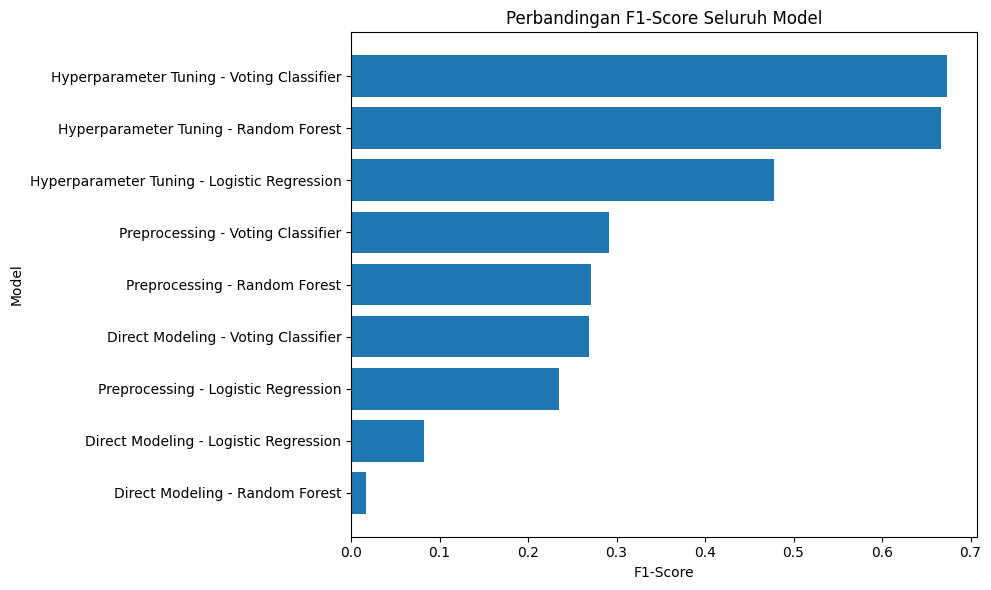

In [17]:
# Membuat label gabungan untuk visualisasi
plot_df = model_results_ranked.copy()
plot_df["Model Label"] = plot_df["Scenario"] + " - " + plot_df["Model"]

plot_f1 = plot_df.sort_values(by="F1-Score", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_f1["Model Label"], plot_f1["F1-Score"])

plt.title("Perbandingan F1-Score Seluruh Model")
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_comparison_f1_score.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Visualisasi Perbandingan Recall

Recall penting pada kasus churn karena menunjukkan kemampuan model dalam menemukan pelanggan yang benar-benar churn.

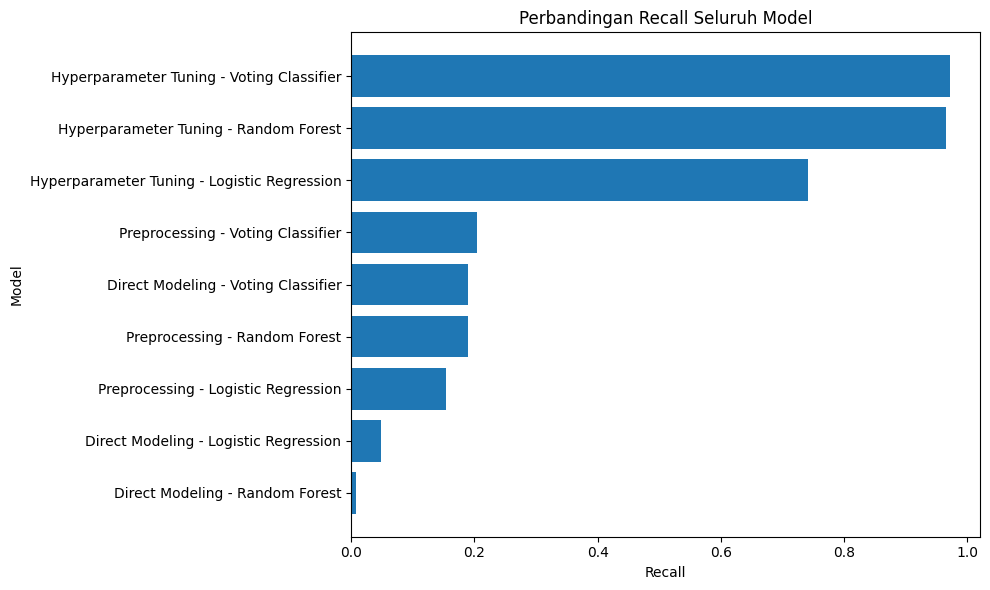

In [18]:
plot_recall = plot_df.sort_values(by="Recall", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_recall["Model Label"], plot_recall["Recall"])

plt.title("Perbandingan Recall Seluruh Model")
plt.xlabel("Recall")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_comparison_recall.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Visualisasi Perbandingan Semua Metrik

Bagian ini menampilkan perbandingan accuracy, precision, recall, dan F1-Score untuk seluruh model.

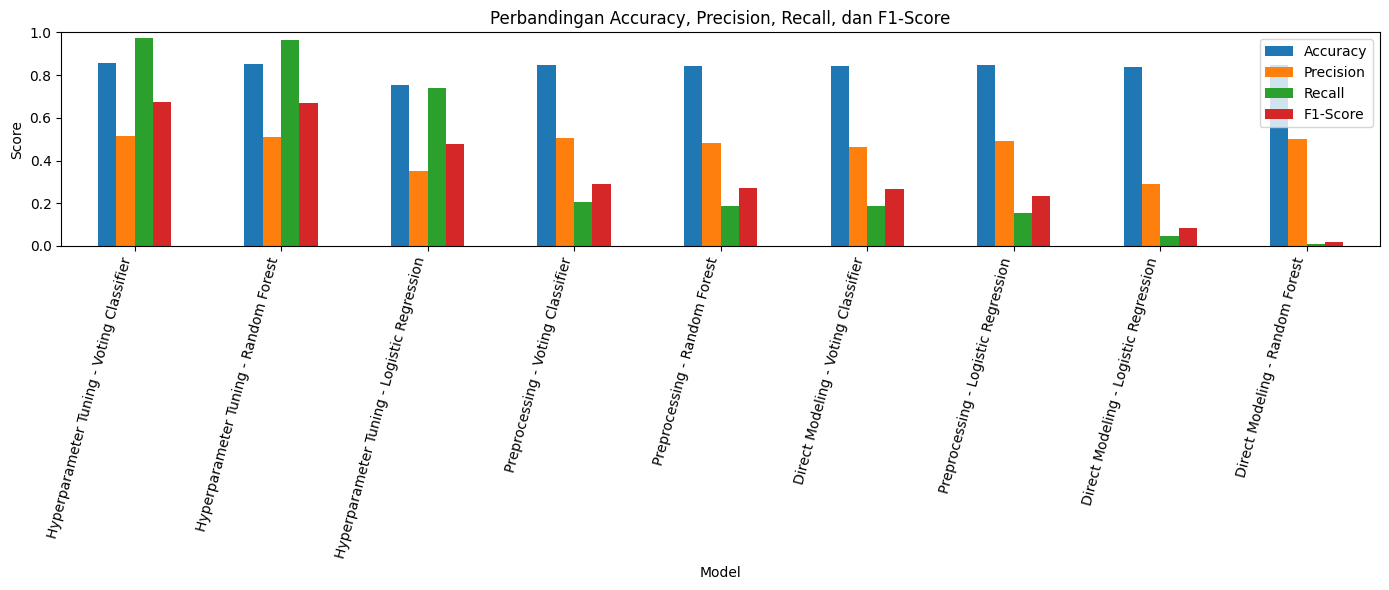

In [19]:
# Menyiapkan data untuk visualisasi semua metrik
metrics_plot_df = model_results_ranked.copy()
metrics_plot_df["Model Label"] = metrics_plot_df["Scenario"] + " - " + metrics_plot_df["Model"]

metrics_plot_df = metrics_plot_df.set_index("Model Label")[metric_cols]

ax = metrics_plot_df.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Perbandingan Accuracy, Precision, Recall, dan F1-Score")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=75, ha="right")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_comparison_all_metrics.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Ringkasan Rata-Rata Performa per Skenario

Bagian ini menghitung rata-rata performa dari setiap skenario. Tujuannya untuk melihat secara umum skenario mana yang memberikan performa lebih baik.

In [20]:
# Rata-rata performa setiap skenario
scenario_summary = (
    model_results
    .groupby("Scenario")[metric_cols]
    .mean()
    .reset_index()
)

scenario_summary

,Scenario,Accuracy,Precision,Recall,F1-Score
0,Direct Modeling,0.841667,0.418238,0.081884,0.122706
1,Hyperparameter Tuning,0.819889,0.459246,0.892754,0.606207
2,Preprocessing,0.845889,0.493032,0.182609,0.265857


In [21]:
scenario_summary.to_csv(
    REPORTS_DIR / "scenario_average_performance.csv",
    index=False
)

print("Rata-rata performa skenario disimpan ke:")
print(REPORTS_DIR / "scenario_average_performance.csv")

Rata-rata performa skenario disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\scenario_average_performance.csv


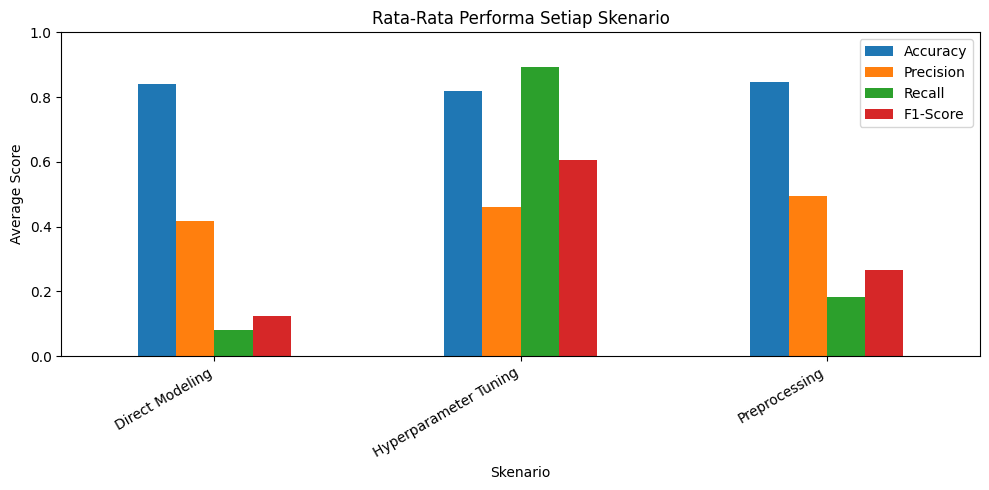

In [22]:
scenario_plot_df = scenario_summary.set_index("Scenario")

ax = scenario_plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Rata-Rata Performa Setiap Skenario")
plt.xlabel("Skenario")
plt.ylabel("Average Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "scenario_average_performance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Validasi Model Terbaik yang Disimpan

Bagian ini mengecek file `best_model.pkl` yang sudah disimpan dari tahap hyperparameter tuning. File ini akan digunakan sebagai kandidat utama untuk tahap deployment.

In [23]:
best_model_path = MODELS_DIR / "best_model.pkl"

if best_model_path.exists():
    best_model_bundle = joblib.load(best_model_path)
    
    print("File best_model.pkl ditemukan.")
    print("Model name dalam bundle:", best_model_bundle.get("model_name", "Tidak tersedia"))
    print("Jumlah selected features:", len(best_model_bundle.get("selected_features", [])))
    print("Best parameters tersedia:", "best_parameters" in best_model_bundle)
else:
    best_model_bundle = None
    print("File best_model.pkl belum ditemukan.")
    print("Pastikan notebook 04_hyperparameter_tuning.ipynb sudah dijalankan.")

File best_model.pkl ditemukan.
Model name dalam bundle: Voting Classifier
Jumlah selected features: 50
Best parameters tersedia: True


In [24]:
# Mengecek kesesuaian model terbaik dari hasil ranking dengan model yang tersimpan
if best_model_bundle is not None:
    saved_model_name = best_model_bundle.get("model_name", None)
    ranked_model_name = best_overall_model["Model"]
    
    print("Model terbaik berdasarkan ranking:", ranked_model_name)
    print("Model tersimpan dalam best_model.pkl:", saved_model_name)
    
    if saved_model_name == ranked_model_name:
        print("Model terbaik sudah sesuai dengan file best_model.pkl.")
    else:
        print("Perhatian: model terbaik ranking berbeda dengan model yang tersimpan.")
        print("Cek ulang hasil notebook 04 dan 05.")

Model terbaik berdasarkan ranking: Voting Classifier
Model tersimpan dalam best_model.pkl: Voting Classifier
Model terbaik sudah sesuai dengan file best_model.pkl.


## Menyimpan Ringkasan Final Model

Ringkasan final model disimpan agar mudah digunakan untuk dokumentasi, laporan, README, dan tahap deployment.

In [25]:
final_summary = {
    "Best Scenario": best_overall_model["Scenario"],
    "Best Model": best_overall_model["Model"],
    "Accuracy": best_overall_model["Accuracy"],
    "Precision": best_overall_model["Precision"],
    "Recall": best_overall_model["Recall"],
    "F1-Score": best_overall_model["F1-Score"],
    "Model File": "models/best_model.pkl"
}

final_summary_df = pd.DataFrame([final_summary])

final_summary_df

,Best Scenario,Best Model,Accuracy,Precision,Recall,F1-Score,Model File
0,Hyperparameter Tuning,Voting Classifier,0.855333,0.514977,0.971739,0.673193,models/best_model.pkl


In [26]:
# Menyimpan ringkasan final model
final_summary_df.to_csv(
    REPORTS_DIR / "final_best_model_summary.csv",
    index=False
)

# Menyimpan versi txt agar mudah dibaca
summary_text = f"""
Final Best Model Summary

Best Scenario : {best_overall_model["Scenario"]}
Best Model    : {best_overall_model["Model"]}
Accuracy      : {best_overall_model["Accuracy"]}
Precision     : {best_overall_model["Precision"]}
Recall        : {best_overall_model["Recall"]}
F1-Score      : {best_overall_model["F1-Score"]}
Model File    : models/best_model.pkl

Catatan:
Model terbaik dipilih berdasarkan F1-Score tertinggi, dengan mempertimbangkan recall, precision, dan accuracy sebagai metrik pendukung.
"""

with open(REPORTS_DIR / "final_best_model_summary.txt", "w", encoding="utf-8") as file:
    file.write(summary_text)

print("Ringkasan final model disimpan ke:")
print(REPORTS_DIR / "final_best_model_summary.csv")
print(REPORTS_DIR / "final_best_model_summary.txt")

Ringkasan final model disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\final_best_model_summary.csv
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\final_best_model_summary.txt


## Kesimpulan Model Comparison

Pada tahap ini, seluruh hasil evaluasi dari direct modeling, preprocessing, dan hyperparameter tuning sudah digabungkan dan dibandingkan.

Model terbaik dipilih berdasarkan F1-Score tertinggi karena kasus churn memiliki distribusi kelas yang tidak seimbang. Recall juga diperhatikan karena model diharapkan mampu mendeteksi pelanggan yang benar-benar berpotensi churn.

Hasil dari notebook ini menjadi dasar untuk tahap berikutnya, yaitu deployment model terbaik menggunakan Streamlit.